In [1]:
%matplotlib inline

import pandas as pd
import sqlalchemy

engine = sqlalchemy.create_engine("sqlite+pysqlite:///data/sales_land_auctions.db")

auctions = pd.read_sql("SELECT * FROM auctions", con=engine)
classificator = pd.read_sql("SELECT * FROM classificator", con=engine)
additional_classificator = pd.read_sql("SELECT * FROM additional_classificator", con=engine)
customers = pd.read_sql("SELECT * FROM customers", con=engine)

display(auctions.head())
display(classificator.head())
display(customers.head())
display(additional_classificator.head())

,auction_id,classificator,additional_classificator,lot_description,land_area,cadastral_number,property_type,start_price,sale_price,customer_edrpou,auction_date,expert_eval_price,lot_address,Latitude,Longitude,oblast,mortgage
0,LSE001-UA-20231006-40023,06111000-3,007.01,Земельна ділянка несільськогосподарського приз...,0.0543,4623610100:02:002:0598,Комунальна,417024.0,459832.0,4372187,2023-11-14,417024.0,"81105 Україна, Львівська область, ПУСТОМИТИ, ,...",49.747980,23.924056,Львівська,0
1,LSE001-UA-20231005-11653,06128000-5,011.00,"Продаж земельної ділянки площею 4,2089 га, кад...",4.2089,7324510100:04:001:0188,Комунальна,3513169.0,4601000.0,4062179,2023-11-13,3513169.0,"59000 Україна, Чернівецька область, Сторожинец...",48.163418,25.718429,Чернівецька,0
2,LSE001-UA-20231010-55788,06112000-0,03.08,Продаж права власності земельної ділянки площе...,0.0150,7110136400:01:012:0028,Комунальна,472800.0,520000.0,38715770,2023-11-10,472800.0,"18018 Україна, Черкаська область, Черкаси, вул...",49.439875,32.082112,Черкаська,0
3,LSE001-UA-20231006-45605,06128000-5,11.02,Продаж земельної ділянки несільськогосподарськ...,0.1224,4610300000:14:040:0108,Комунальна,190592.0,192592.0,26181298,2023-11-08,190592.0,"82300 Україна, Львівська область, м.Борислав, ...",49.300083,23.422556,Львівська,0
4,LSE001-UA-20231006-90766,06128000-5,11.02,Продаж земельної ділянки несільськогосподарськ...,0.0429,4610300000:14:040:0107,Комунальна,67182.0,70000.0,26181298,2023-11-08,67182.0,"82300 Україна, Львівська область, м.Борислав, ...",49.297918,23.425799,Львівська,0


,classificator_code,classificator_description,classificator_class
0,06111000-3,"Землі житлової забудови (землі, які використо...",housing
1,06128000-5,"Землі промисловості, транспорту, зв'язку, ене...",industry_infrastructure
2,06112000-0,"Землі громадської забудови (землі, які викори...",public_development
3,06121000-6,Землі сільськогосподарського призначення,agriculture
4,06124000-7,Землі рекреаційного призначення,recreational


,customer_edrpou,customer_name,customer_address
0,4372187,Пустомитівська міська рада Львівського району ...,"81100 Україна, м.Пустомити, Львівська область,..."
1,4062179,СТОРОЖИНЕЦЬКА МІСЬКА РАДА,"59000 Україна, Сторожинець, Чернівецька област..."
2,38715770,Департамент архітектури та містобудування Черк...,"18000 Україна, Черкаси, Черкаська область, Бай..."
3,26181298,Бориславська міська рада,"82300 Україна, м. Борислав, Львівська область,..."
4,4051336,ЛЮБОМЛЬСЬКА МІСЬКА РАДА,"44300 Україна, м.Любомль, Волинська область, в..."


,code,code_description
0,007.01,Малоповерхова забудова
1,011.00,Землі під промисловою забудовою
2,03.08,Для будівництва та обслуговування об'єктів тур...
3,11.02,"Для розміщення та експлуатації основних, підсо..."
4,12.04,Для розміщення та експлуатації будівель і спор...


In [2]:
auctions.info()
classificator.info()
customers.info()
additional_classificator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   auction_id                1596 non-null   object 
 1   classificator             1596 non-null   object 
 2   additional_classificator  1596 non-null   object 
 3   lot_description           1596 non-null   object 
 4   land_area                 1596 non-null   float64
 5   cadastral_number          1596 non-null   object 
 6   property_type             1596 non-null   object 
 7   start_price               1596 non-null   float64
 8   sale_price                1596 non-null   float64
 9   customer_edrpou           1596 non-null   object 
 10  auction_date              1596 non-null   object 
 11  expert_eval_price         1569 non-null   float64
 12  lot_address               1596 non-null   object 
 13  Latitude                  1596 non-null   float64
 14  Longitud

In [3]:
auctions["auction_date"] = pd.to_datetime(auctions["auction_date"])
auctions = auctions.astype({
    "mortgage": "bool",
    "oblast": "category",
    "classificator": "category",
    "additional_classificator": "category",
    "property_type": "category",
})
auctions.info()

classificator = classificator.astype({
    "classificator_code": "category",
    "classificator_class": "category",
})
classificator.info()

additional_classificator = additional_classificator.astype({
    "code": "category",
})
additional_classificator.info()

customers = customers.astype({
    "customer_edrpou": "category",
})
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   auction_id                1596 non-null   object        
 1   classificator             1596 non-null   category      
 2   additional_classificator  1596 non-null   category      
 3   lot_description           1596 non-null   object        
 4   land_area                 1596 non-null   float64       
 5   cadastral_number          1596 non-null   object        
 6   property_type             1596 non-null   category      
 7   start_price               1596 non-null   float64       
 8   sale_price                1596 non-null   float64       
 9   customer_edrpou           1596 non-null   object        
 10  auction_date              1596 non-null   datetime64[ns]
 11  expert_eval_price         1569 non-null   float64       
 12  lot_address         

In [4]:
import data_profiling

profiler = data_profiling.ProfileReport(auctions)
profiler.to_file("data/auctions.html")

C:\Users\romab\Desktop\data_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 99.41it/s]


In [5]:
auctions.sort_values('land_area', ascending=False).head(10)[['auction_id', 'land_area', 'lot_description']]

,auction_id,land_area,lot_description
355,LSE001-UA-20230609-89341,3179.0000,"Земельна ділянка, реєстраційний/кадастровий но..."
1422,LSE001-UA-20220113-94743,17.5637,"Земельна ділянка, площею 17,5637 га, кадастров..."
1538,LSE001-UA-20211117-50810,15.0000,Продаж земельної ділянки несільськогосподарськ...
469,LSP001-UA-20230502-65407,14.2440,Земельна ділянка Кадастровий номер: 3522585000...
857,LSE001-UA-20230113-81387,14.0365,Продаж земельної ділянки несільськогосподарськ...
787,LSE001-UA-20230206-69026,13.8936,"Земельна ділянка, площа 13,8936 га, для веденн..."
1370,LSE001-UA-20220324-90738,13.8000,Земельна ділянка несільськогосподарського приз...
1173,LSP001-UA-20220902-67850,13.4300,ЗЕМЕЛЬНА ДІЛЯНКА. Кадастровий номер 1224580500...
552,LSE001-UA-20230407-57333,13.0000,"ІПОТЕКА.Земельна ділянка, площею 13.0000 га., ..."
605,LSE001-UA-20230313-81907,12.7383,Іпотека. Земельна ділянка (кадастровий номер 3...


In [6]:
auctions.loc[auctions['auction_id'] == 'LSE001-UA-20230609-89341', 'land_area'] = pd.NA
auctions['land_area'].isna().sum()

np.int64(1)

In [7]:
auctions.to_csv('data/auctions.csv', index=False)
classificator.to_csv('data/classificator.csv', index=False)
additional_classificator.to_csv('data/additional_classificator.csv', index=False)
customers.to_csv('data/customers.csv', index=False)

In [8]:
auctions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   auction_id                1596 non-null   object        
 1   classificator             1596 non-null   category      
 2   additional_classificator  1596 non-null   category      
 3   lot_description           1596 non-null   object        
 4   land_area                 1595 non-null   float64       
 5   cadastral_number          1596 non-null   object        
 6   property_type             1596 non-null   category      
 7   start_price               1596 non-null   float64       
 8   sale_price                1596 non-null   float64       
 9   customer_edrpou           1596 non-null   object        
 10  auction_date              1596 non-null   datetime64[ns]
 11  expert_eval_price         1569 non-null   float64       
 12  lot_address         

In [9]:
area_by_oblast = auctions.groupby('oblast', observed=True)['land_area'].sum(min_count=1)
area_by_oblast = area_by_oblast.sort_values(ascending=False)
area_by_oblast

oblast
Одеська              379.4773
Дніпропетровська     300.6960
Полтавська           294.5786
Чернігівська         258.7536
Київська             256.8437
Кіровоградська       254.1767
Черкаська            223.6999
Хмельницька          196.4711
Львівська            118.9082
Вінницька             80.4282
Рівненська            60.5136
Волинська             54.1642
Сумська               46.7456
Харківська            44.2952
Житомирська           35.9589
Миколаївська          35.6515
Чернівецька           35.3947
Запорізька            29.0542
Тернопільська         25.8572
Івано-Франківська     23.4306
Закарпатська          20.2579
Київ                   0.8278
Name: land_area, dtype: float64

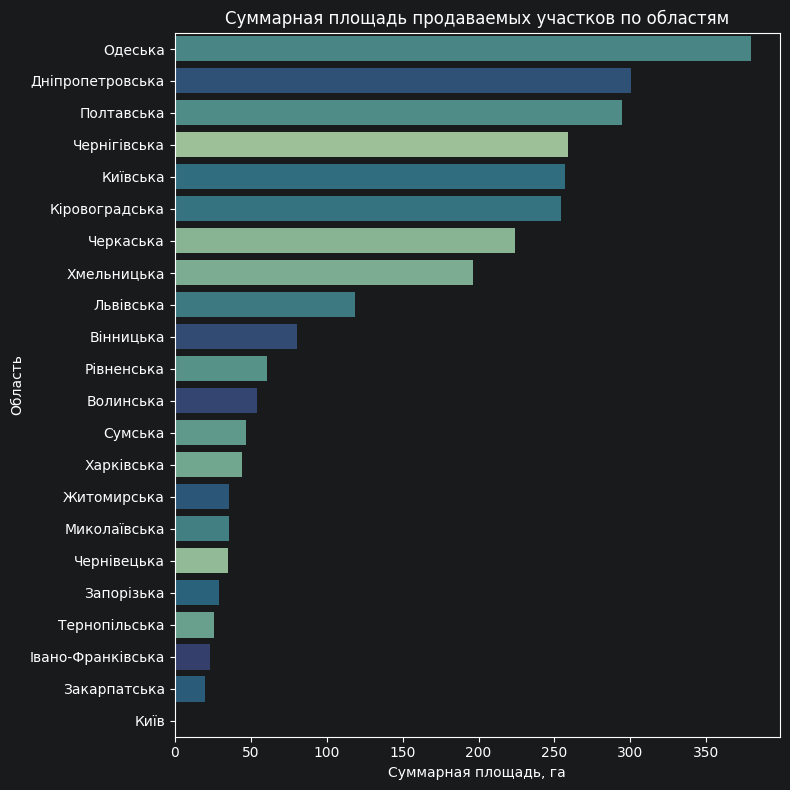

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

plt.figure(figsize=(8, 8))
sns.barplot(
    x=area_by_oblast.values,
    y=area_by_oblast.index,
    order=area_by_oblast.index,
    hue=area_by_oblast.index,
    legend=False,
    palette='crest_r'
)
plt.xlabel('Суммарная площадь, га')
plt.ylabel('Область')
plt.title('Суммарная площадь продаваемых участков по областям')
plt.tight_layout()
plt.show()

In [12]:
lots_by_oblast = auctions.groupby('oblast', observed=True).size()
lots_by_oblast = lots_by_oblast.sort_values(ascending=False)
lots_by_oblast

oblast
Львівська            202
Київська             182
Черкаська            130
Хмельницька          123
Чернігівська         107
Одеська              103
Полтавська            94
Волинська             94
Дніпропетровська      83
Рівненська            78
Кіровоградська        74
Чернівецька           72
Закарпатська          64
Вінницька             44
Тернопільська         37
Житомирська           30
Івано-Франківська     28
Сумська               18
Харківська            13
Запорізька             8
Миколаївська           6
Київ                   6
dtype: int64

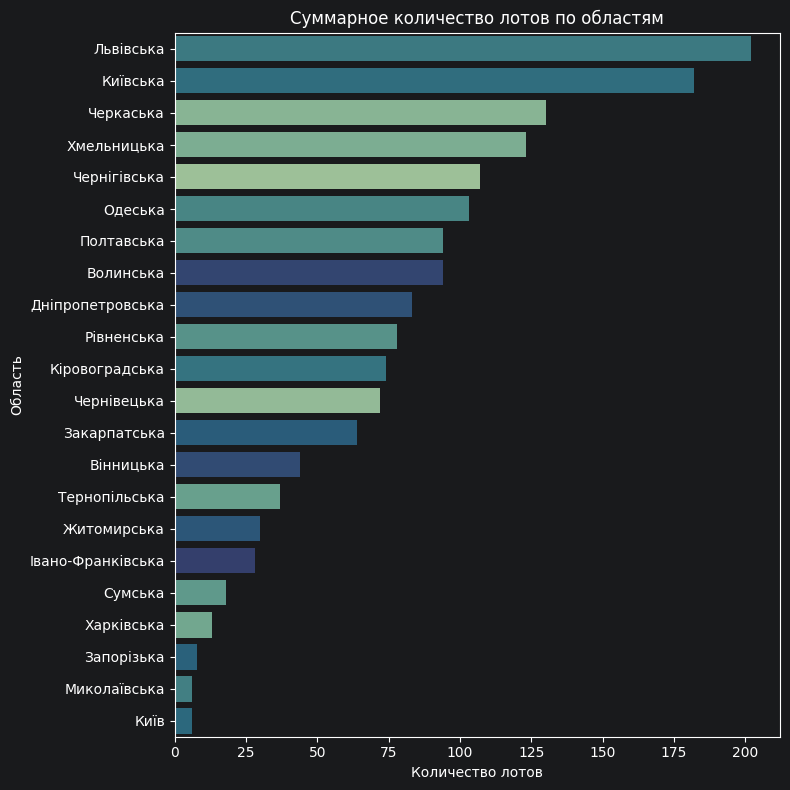

In [13]:
plt.figure(figsize=(8, 8))
sns.barplot(
    x=lots_by_oblast.values,
    y=lots_by_oblast.index,
    order=lots_by_oblast.index,
    hue=lots_by_oblast.index,
    legend=False,
    palette='crest_r'
)
plt.xlabel('Количество лотов')
plt.ylabel('Область')
plt.title('Суммарное количество лотов по областям')
plt.tight_layout()
plt.show()

In [14]:
auctions['year'] = auctions['auction_date'].dt.year

lots_by_year_oblast = (
    auctions.groupby(['oblast', 'year'], observed=True)
    .size()
    .unstack(fill_value=0)
)
lots_by_year_oblast = lots_by_year_oblast.loc[lots_by_year_oblast.sum(axis=1).sort_values(ascending=False).index]
lots_by_year_oblast

year,2021,2022,2023
oblast,,,
Львівська,14,70,118
Київська,20,52,110
Черкаська,4,37,89
Хмельницька,7,35,81
Чернігівська,2,45,60
Одеська,0,28,75
Полтавська,0,40,54
Волинська,6,37,51
Дніпропетровська,0,40,43


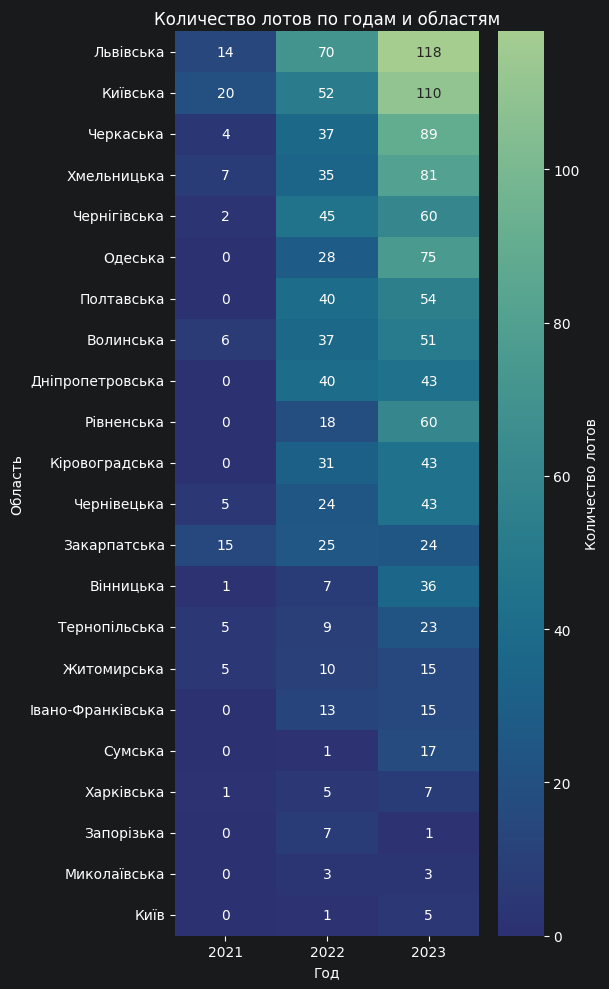

In [19]:
plt.figure(figsize=(6, 10))
sns.heatmap(lots_by_year_oblast, annot=True, fmt='d', cmap='crest_r', cbar_kws={'label': 'Количество лотов'})
plt.xlabel('Год')
plt.ylabel('Область')
plt.title('Количество лотов по годам и областям')
plt.tight_layout()
plt.show()

In [20]:
type_by_oblast = (
    auctions.groupby(['oblast', 'classificator'], observed=True)
    .size()
    .reset_index(name='count')
)

top_type_by_oblast = type_by_oblast.loc[
    type_by_oblast.groupby('oblast', observed=True)['count'].idxmax()
]

top_type_by_oblast = top_type_by_oblast.merge(
    classificator,
    left_on='classificator',
    right_on='classificator_code',
    how='left'
)[['oblast', 'classificator', 'classificator_description', 'count']]

top_type_by_oblast = top_type_by_oblast.sort_values('count', ascending=False)
top_type_by_oblast

,oblast,classificator,classificator_description,count
8,Київська,06121000-6,Землі сільськогосподарського призначення,119
12,Одеська,06121000-6,Землі сільськогосподарського призначення,101
21,Чернігівська,06121000-6,Землі сільськогосподарського призначення,98
19,Черкаська,06121000-6,Землі сільськогосподарського призначення,98
10,Львівська,06112000-0,"Землі громадської забудови (землі, які викори...",97
13,Полтавська,06121000-6,Землі сільськогосподарського призначення,86
9,Кіровоградська,06121000-6,Землі сільськогосподарського призначення,67
18,Хмельницька,06121000-6,Землі сільськогосподарського призначення,67
3,Дніпропетровська,06121000-6,Землі сільськогосподарського призначення,61
1,Волинська,06128000-5,"Землі промисловості, транспорту, зв'язку, ене...",40


In [24]:
industrial = auctions[auctions['additional_classificator'] == '011.00']

industrial_by_oblast = (
    industrial.groupby('oblast', observed=True)
    .size()
    .sort_values(ascending=False)
)

industrial_by_oblast

oblast
Черкаська      3
Чернівецька    1
dtype: int64

In [25]:
additional_classificator[additional_classificator['code_description'].str.contains('промислов', case=False, na=False)]

,code,code_description
1,011.00,Землі під промисловою забудовою
3,11.02,"Для розміщення та експлуатації основних, підсо..."
18,011.01,Землі під будівлями та спорудами промислових п...
56,11,Земельні ділянки промисловості


In [26]:
auctions['additional_classificator'].value_counts().head(20)

additional_classificator
01.01     472
03.07     204
01.03     192
11.02     145
01        127
02.01      80
03.10      45
03.15      33
01.05      24
12.11      20
001.00     19
02.03      18
02.09      18
001.01     17
12.08      15
12.04      12
11.03      10
07.03      10
03.08      10
002.00      8
Name: count, dtype: int64

In [27]:
purpose_by_oblast = (
    auctions.groupby(['oblast', 'additional_classificator'], observed=True)
    .size()
    .reset_index(name='count')
)

purpose_pivot = purpose_by_oblast.pivot(index='oblast', columns='additional_classificator', values='count').fillna(0).astype(int)
purpose_pivot = purpose_pivot.loc[purpose_pivot.sum(axis=1).sort_values(ascending=False).index]
purpose_pivot

additional_classificator,001.00,001.01,001.02,002.00,002.01,002.02,003.00,003.04,004.00,007.00,...,11.01,11.02,11.03,11.04,12,12.02,12.04,12.08,12.09,12.11
oblast,,,,,,,,,,,,,,,,,,,,,
Львівська,0,0,0,0,0,0,0,0,0,0,...,0,43,3,0,0,0,5,8,0,6
Київська,6,5,5,6,0,0,0,0,1,2,...,0,7,0,0,0,0,0,0,1,0
Черкаська,5,3,1,0,0,0,0,0,0,3,...,0,2,0,0,0,0,1,0,0,3
Хмельницька,0,0,0,0,0,0,0,0,0,0,...,0,23,2,0,0,0,0,1,0,1
Чернігівська,1,5,0,0,1,1,0,0,0,0,...,0,5,0,0,0,0,0,0,0,1
Одеська,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Полтавська,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,1,0,0
Волинська,0,0,0,0,0,0,0,0,0,0,...,0,16,3,2,0,6,5,2,0,6
Дніпропетровська,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


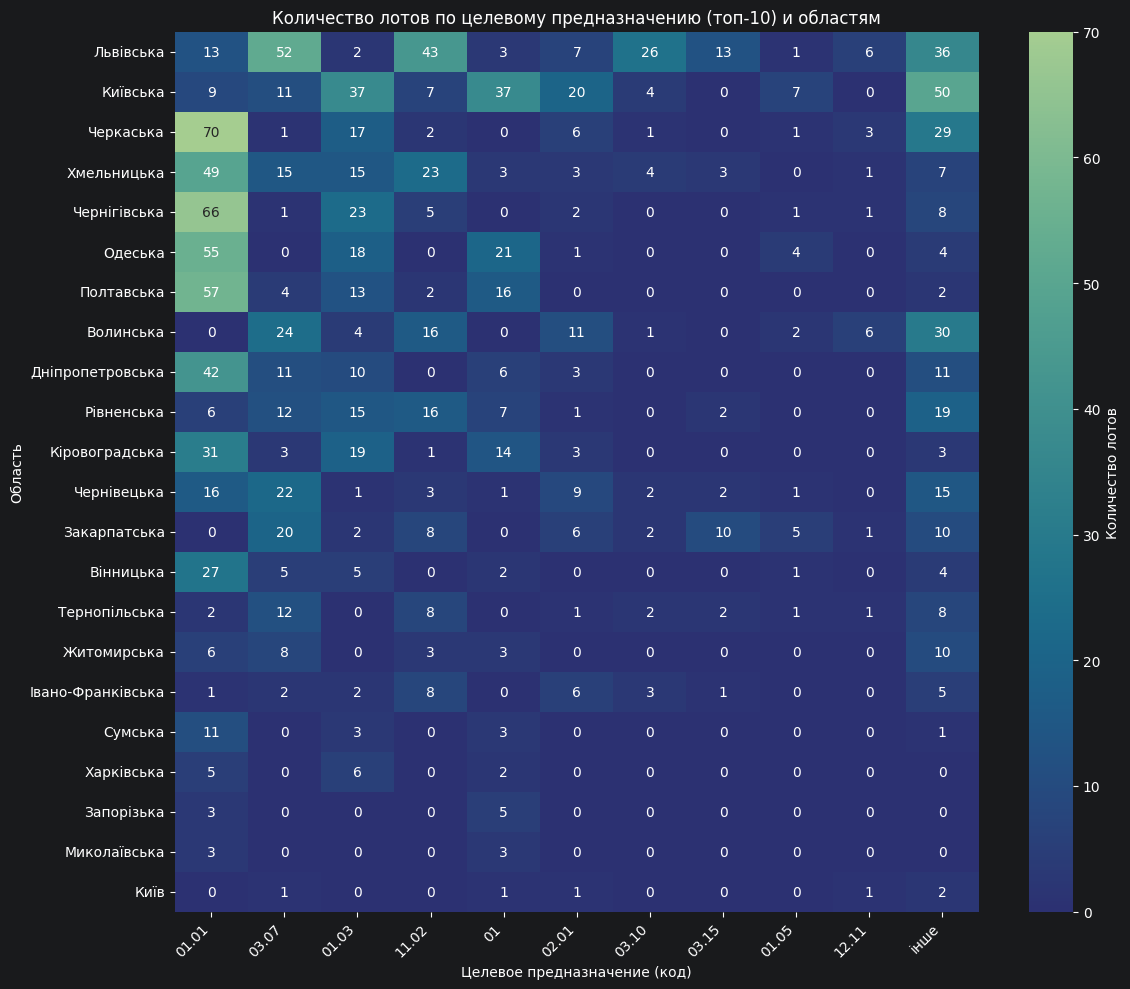

In [28]:
top_n = 10
top_codes = auctions['additional_classificator'].value_counts().head(top_n).index

purpose_pivot_top = purpose_pivot[top_codes].copy()
purpose_pivot_top['інше'] = purpose_pivot.drop(columns=top_codes).sum(axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(purpose_pivot_top, annot=True, fmt='d', cmap='crest_r', cbar_kws={'label': 'Количество лотов'})
plt.xlabel('Целевое предназначение (код)')
plt.ylabel('Область')
plt.title(f'Количество лотов по целевому предназначению (топ-{top_n}) и областям')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
import requests

start_date = auctions['auction_date'].min()
end_date = auctions['auction_date'].max()

url = "https://bank.gov.ua/NBU_Exchange/exchange_site"
params = {
    "start": start_date.strftime("%Y%m%d"),
    "end": end_date.strftime("%Y%m%d"),
    "valcode": "eur",
    "sort": "exchangedate",
    "json": ""
}

response = requests.get(url, params=params)
eur_rates = pd.DataFrame(response.json())
eur_rates['exchangedate'] = pd.to_datetime(eur_rates['exchangedate'], format='%d.%m.%Y')

eur_rates = eur_rates[['exchangedate', 'rate']].rename(columns={'rate': 'eur_rate'})
eur_rates

,exchangedate,eur_rate
0,2021-11-08,30.0969
1,2021-11-09,30.2026
2,2021-11-10,30.2075
3,2021-11-11,30.1186
4,2021-11-12,29.9144
...,...,...
732,2023-11-10,38.5225
733,2023-11-11,38.5225
734,2023-11-12,38.5225
735,2023-11-13,38.5420


In [30]:
auctions = auctions.merge(eur_rates, left_on='auction_date', right_on='exchangedate', how='left')

auctions['start_price_eur'] = auctions['start_price'] / auctions['eur_rate']
auctions['sale_price_eur'] = auctions['sale_price'] / auctions['eur_rate']
auctions['expert_eval_price_eur'] = auctions['expert_eval_price'] / auctions['eur_rate']

auctions[['auction_date', 'eur_rate', 'start_price', 'start_price_eur', 'sale_price', 'sale_price_eur']].head()

,auction_date,eur_rate,start_price,start_price_eur,sale_price,sale_price_eur
0,2023-11-14,38.5945,417024.0,10805.270181,459832.0,11914.443768
1,2023-11-13,38.5420,3513169.0,91151.704634,4601000.0,119376.264854
2,2023-11-10,38.5225,472800.0,12273.346745,520000.0,13498.604712
3,2023-11-08,38.4840,190592.0,4952.499740,192592.0,5004.469390
4,2023-11-08,38.4840,67182.0,1745.712504,70000.0,1818.937740


In [31]:
print(len(auctions))
auctions['eur_rate'].isna().sum()

1596


np.int64(0)

In [32]:
fig = px.line(eur_rates, x='exchangedate', y='eur_rate', title='Курс EUR/UAH (НБУ) за период аукционов')
fig.update_layout(xaxis_title='Дата', yaxis_title='Курс, грн за 1 EUR')
fig.show()

In [38]:
pd.set_option('display.float_format', '{:,.2f}'.format)


auctions['price_per_ha_eur'] = auctions['sale_price_eur'] / auctions['land_area']

price_per_ha = (
    auctions.groupby(['oblast', 'classificator'], observed=True)['price_per_ha_eur']
    .mean()
    .reset_index()
)

price_per_ha_pivot = price_per_ha.pivot(index='oblast', columns='classificator', values='price_per_ha_eur')
price_per_ha_pivot

classificator,06111000-3,06112000-0,06121000-6,06123000-0,06124000-7,06128000-5
oblast,,,,,,
Івано-Франківська,"133,446.29","237,566.33","20,827.50","477,833.88","12,036.75","97,375.29"
Волинська,"115,618.50","176,757.39","14,232.68",NaN,"22,930.18","62,752.89"
Вінницька,"267,405.13","145,782.03","7,201.85",NaN,"23,746.37","15,779.40"
Дніпропетровська,"45,692.45","853,673.13","1,411.32",NaN,"182,288.15",NaN
Житомирська,"102,465.67","82,815.36","1,539.98",NaN,NaN,"34,889.87"
Закарпатська,"95,509.94","200,204.83","38,110.38",NaN,"101,802.98","87,441.99"
Запорізька,NaN,NaN,"1,499.57",NaN,NaN,NaN
Київ,"1,252,733.59","2,605,156.62","216,389.88",NaN,NaN,"1,039,676.05"
Київська,"173,324.64","755,260.08","22,234.60",NaN,"93,758.19","65,251.80"


In [39]:
code_to_name = classificator.set_index('classificator_code')['classificator_description']
price_per_ha_pivot_named = price_per_ha_pivot.rename(columns=code_to_name)
price_per_ha_pivot_named

classificator,"Землі житлової забудови (землі, які використовуються для розміщення житлової забудови (житлові будинки, гуртожитки, господарські будівлі та інше); землі, які використовуються для розміщення гаражного будівництва)","Землі громадської забудови (землі, які використовуються для розміщення громадських будівель і споруд (готелів, офісних будівель, торговельних будівель, для публічних виступів, для музеїв та бібліотек, для навчальних та дослідних закладів, для лікарень та оздоровчих закладів), інших об'єктів загального користування)",Землі сільськогосподарського призначення,Землі оздоровчого призначення,Землі рекреаційного призначення,"Землі промисловості, транспорту, зв'язку, енергетики, оборони та іншого призначення"
oblast,,,,,,
Івано-Франківська,"133,446.29","237,566.33","20,827.50","477,833.88","12,036.75","97,375.29"
Волинська,"115,618.50","176,757.39","14,232.68",NaN,"22,930.18","62,752.89"
Вінницька,"267,405.13","145,782.03","7,201.85",NaN,"23,746.37","15,779.40"
Дніпропетровська,"45,692.45","853,673.13","1,411.32",NaN,"182,288.15",NaN
Житомирська,"102,465.67","82,815.36","1,539.98",NaN,NaN,"34,889.87"
Закарпатська,"95,509.94","200,204.83","38,110.38",NaN,"101,802.98","87,441.99"
Запорізька,NaN,NaN,"1,499.57",NaN,NaN,NaN
Київ,"1,252,733.59","2,605,156.62","216,389.88",NaN,NaN,"1,039,676.05"
Київська,"173,324.64","755,260.08","22,234.60",NaN,"93,758.19","65,251.80"


In [40]:
auctions[
    (auctions['oblast'] == 'Київ') &
    (auctions['classificator'] == '06111000-3')
][['land_area', 'sale_price_eur', 'price_per_ha_eur']]

,land_area,sale_price_eur,price_per_ha_eur
75,0.40,"766,205.24","1,919,832.73"
223,0.02,"30,384.01","1,519,200.63"
961,0.10,"31,916.74","319,167.41"


C:\Users\romab\AppData\Local\Temp\ipykernel_23212\1587306669.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


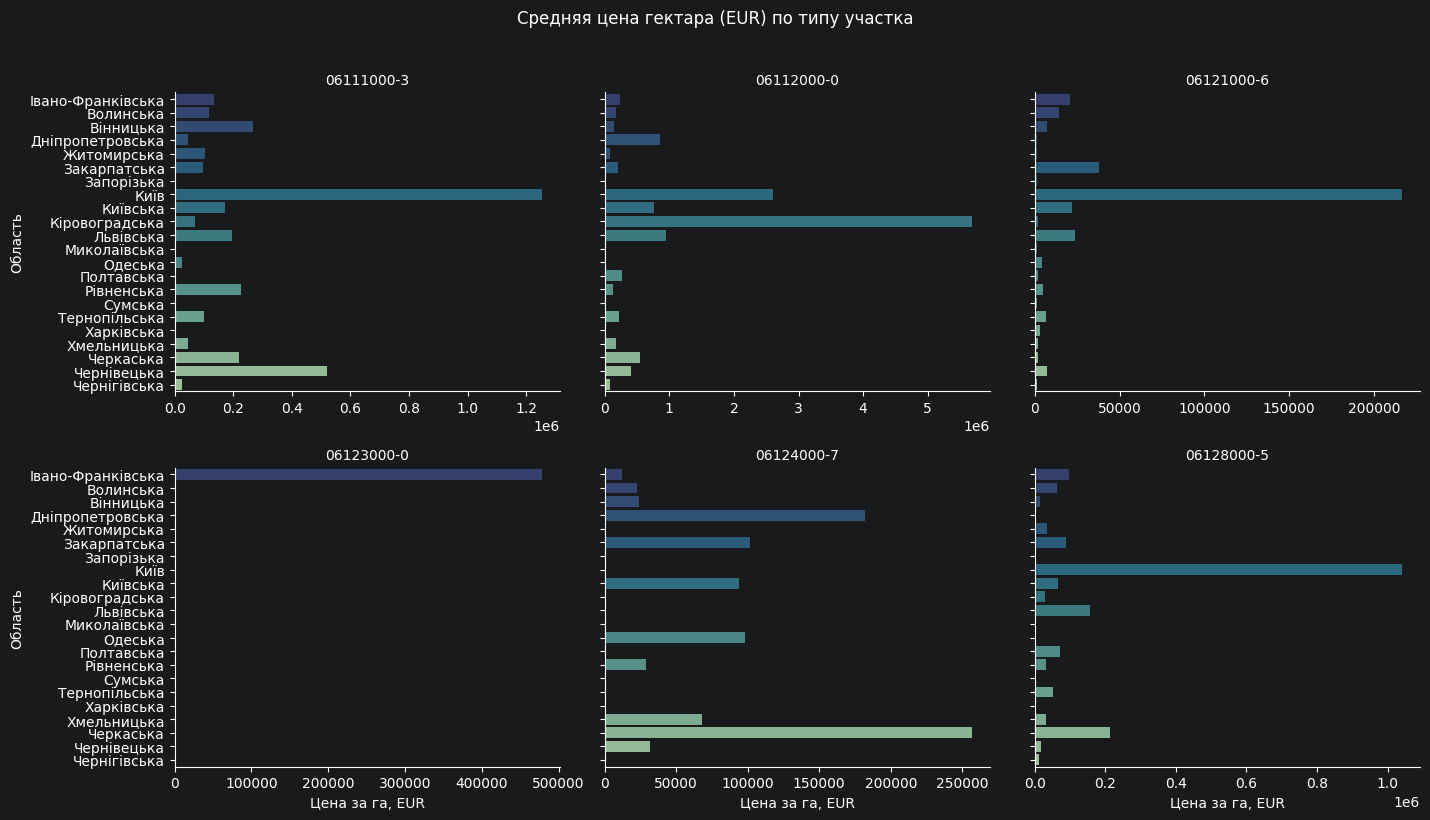

In [50]:
g = sns.catplot(
    data=price_per_ha.dropna(subset=['price_per_ha_eur']),
    x='price_per_ha_eur', y='oblast',
    col='classificator', col_wrap=3,
    kind='bar', sharex=False,
    height=4, aspect=1.2,
    palette='crest_r'
)
g.set_titles('{col_name}')
g.set_axis_labels('Цена за га, EUR', 'Область')
g.fig.suptitle('Средняя цена гектара (EUR) по типу участка', y=1.02)
plt.tight_layout()
plt.show()

In [54]:
auctions['eval_error_abs_eur'] = auctions['eval_error_eur'].abs()

error_abs_by_purpose = (
    auctions.groupby('additional_classificator', observed=True)['eval_error_abs_eur']
    .mean()
    .sort_values(ascending=False)
)
error_abs_by_purpose

additional_classificator
06.01    508,680.26
02.10    242,936.16
07.02    122,000.44
03        70,818.25
007.02    62,597.60
03.08     50,127.62
03.10     39,342.13
02.03     39,122.55
008.03    38,924.94
02.09     37,548.55
011.00    30,371.56
12.02     28,570.92
03.02     20,775.38
03.15     20,282.76
11.03     19,398.33
11.02     18,271.59
12.08     15,319.73
004.00    13,843.84
02        13,553.37
008.00     9,972.19
03.07      9,711.49
07.03      9,519.75
12.11      8,774.68
009.00     8,662.94
12.04      6,356.61
007.00     5,605.56
07.01      4,629.41
013.00     3,970.42
11.04      3,829.20
02.01      3,802.61
11         3,719.26
12.09      3,334.88
01.02      3,230.65
01.05      2,553.07
002.00     1,691.36
001.02     1,544.04
001.00     1,411.85
007.01     1,302.29
01.01      1,298.87
01.03      1,225.98
01.04      1,205.33
01         1,132.68
03.05      1,055.89
11.01        844.92
001.01       833.32
014.00       816.45
01.06        719.83
02.05        635.62
012.00       56

In [55]:
error_abs_by_purpose[error_abs_by_purpose.isna()]

additional_classificator
12   NaN
Name: eval_error_abs_eur, dtype: float64

In [56]:
missing_code = error_abs_by_purpose[error_abs_by_purpose.isna()].index[0]
auctions[auctions['additional_classificator'] == missing_code]['expert_eval_price'].isna().sum()

np.int64(2)

In [59]:
auctions[auctions['additional_classificator'] == '12'][['auction_id', 'additional_classificator', 'expert_eval_price']]

,auction_id,additional_classificator,expert_eval_price
1205,LSE001-UA-20220819-06564,12,NaN
1303,LSE001-UA-20220615-00495,12,NaN


In [60]:
auctions['additional_classificator'].cat.categories.tolist()

['001.00',
 '001.01',
 '001.02',
 '002.00',
 '002.01',
 '002.02',
 '003.00',
 '003.04',
 '004.00',
 '007.00',
 '007.01',
 '007.02',
 '008.00',
 '008.03',
 '009.00',
 '01',
 '01.01',
 '01.02',
 '01.03',
 '01.04',
 '01.05',
 '01.06',
 '011.00',
 '011.01',
 '012.00',
 '013.00',
 '014.00',
 '02',
 '02.01',
 '02.03',
 '02.05',
 '02.09',
 '02.10',
 '03',
 '03.02',
 '03.03',
 '03.05',
 '03.07',
 '03.08',
 '03.10',
 '03.13',
 '03.15',
 '06.01',
 '07.01',
 '07.02',
 '07.03',
 '11',
 '11.01',
 '11.02',
 '11.03',
 '11.04',
 '12',
 '12.02',
 '12.04',
 '12.08',
 '12.09',
 '12.11']

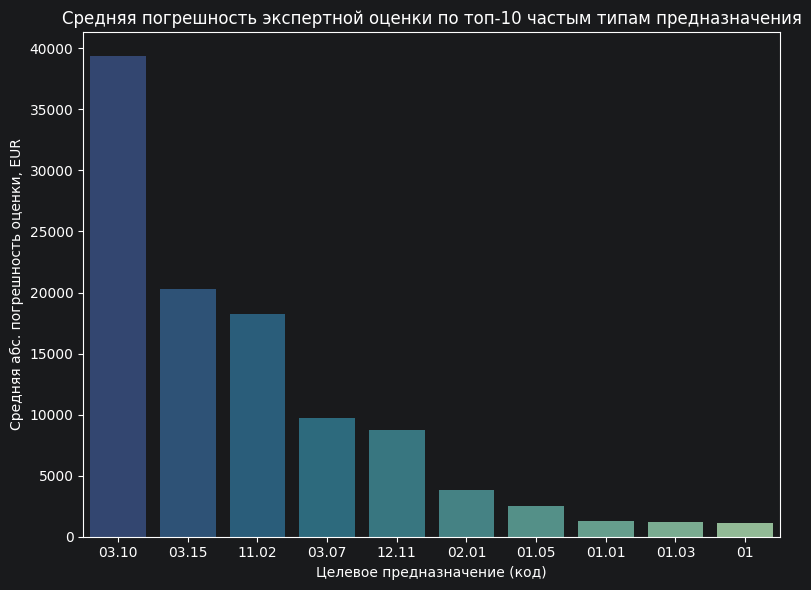

In [63]:
plt.figure(figsize=(8, 6))
sns.barplot(x=error_abs_top.index, y=error_abs_top.values, order=error_abs_top.index, hue=error_abs_top.index, legend=False, palette='crest_r')
plt.xlabel('Целевое предназначение (код)')
plt.ylabel('Средняя абс. погрешность оценки, EUR')
plt.title('Средняя погрешность экспертной оценки по топ-10 частым типам предназначения')
plt.tight_layout()
plt.show()

In [64]:
lots_by_oblast_customer = (
    auctions.groupby(['oblast', 'customer_edrpou'], observed=True)
    .agg(lots_count=('auction_id', 'size'), total_sale_eur=('sale_price_eur', 'sum'))
    .reset_index()
)

max_lots_per_oblast = lots_by_oblast_customer.groupby('oblast', observed=True)['lots_count'].transform('max')
top_customers_by_oblast = lots_by_oblast_customer[lots_by_oblast_customer['lots_count'] == max_lots_per_oblast]

top_customers_by_oblast = top_customers_by_oblast.merge(
    customers[['customer_edrpou', 'customer_name']],
    on='customer_edrpou',
    how='left'
)

top_customers_by_oblast = top_customers_by_oblast.sort_values(['oblast', 'lots_count'], ascending=[True, False])
top_customers_by_oblast

,oblast,customer_edrpou,lots_count,total_sale_eur,customer_name
0,Івано-Франківська,33644700,7,"98,864.17",ІВАНО-ФРАНКІВСЬКА МІСЬКА РАДА (підписант - Деп...
1,Волинська,21735504,23,"1,359,386.05",КОВЕЛЬСЬКА МІСЬКА РАДА
2,Вінницька,3017114656,10,"46,988.31",Приватний виконавець Тимощук Володимир Вікторович
3,Дніпропетровська,3228512088,25,"136,079.29",Приватний виконавець Русецька Оксана Олександр...
4,Житомирська,4053370,5,"61,411.35",Овруцька міська рада
5,Закарпатська,34005221,10,"118,706.36","Хустська міська рада, Закарпатської області"
6,Запорізька,3104805273,7,"28,528.58",Приватний виконавець Безмагоричних Микита Андр...
7,Київ,26199097,2,"973,412.68",ДЕПАРТАМЕНТ ЗЕМЕЛЬНИХ РЕСУРСІВ ВИКОНАВЧОГО ОРГ...
8,Київська,2605408729,34,"23,512.77",Приватний виконавець виконавчого округу міста ...
9,Кіровоградська,3115318390,13,"37,033.12",Приватний виконавець виконавчого округу Кірово...


In [65]:
top_customers_by_oblast['oblast'].value_counts()

oblast
Миколаївська         6
Івано-Франківська    1
Вінницька            1
Дніпропетровська     1
Житомирська          1
Волинська            1
Закарпатська         1
Запорізька           1
Київська             1
Київ                 1
Кіровоградська       1
Львівська            1
Одеська              1
Полтавська           1
Рівненська           1
Сумська              1
Тернопільська        1
Харківська           1
Хмельницька          1
Черкаська            1
Чернівецька          1
Чернігівська         1
Name: count, dtype: int64

In [66]:
top_customers_by_oblast[top_customers_by_oblast['oblast'] == 'Миколаївська']

,oblast,customer_edrpou,lots_count,total_sale_eur,customer_name
11,Миколаївська,34993707,1,"3,631.22",Первомайський ВДВС у Первомайському районі Мик...
12,Миколаївська,2963108096,1,"9,250.22",Приватний виконавець виконавчого округу Микола...
13,Миколаївська,3157424394,1,"2,263.97",Приватний виконавець виконавчого округу Микола...
14,Миколаївська,3228512082,1,"7,784.60",Приватний виконавець Русецька Оксана Олександр...
15,Миколаївська,3228512088,1,"4,728.53",Приватний виконавець Русецька Оксана Олександр...
16,Миколаївська,3338711211,1,"16,748.78",Приватний виконавець виконавчого округу Черкас...


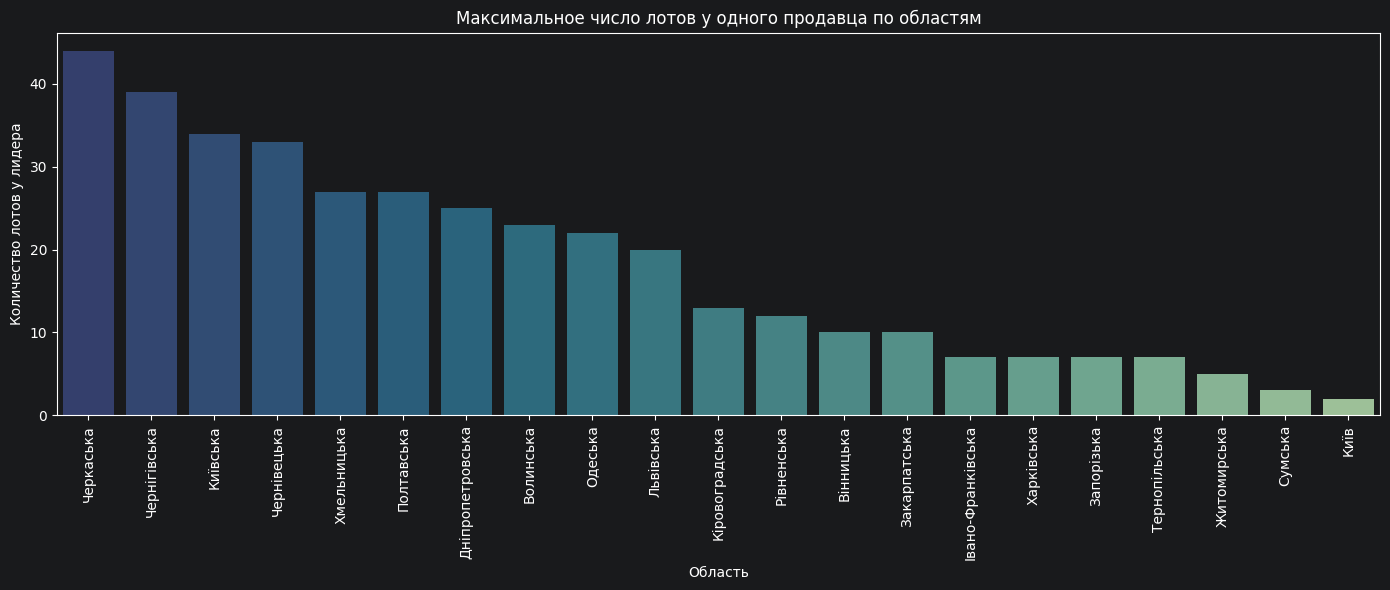

In [69]:
plot_data = top_customers_by_oblast[top_customers_by_oblast['oblast'] != 'Миколаївська'].copy()
plot_data['oblast'] = plot_data['oblast'].astype(str)
plot_data = plot_data.sort_values('lots_count', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x='oblast', y='lots_count', data=plot_data, order=plot_data['oblast'], hue='oblast', legend=False, palette='crest_r')
plt.xlabel('Область')
plt.ylabel('Количество лотов у лидера')
plt.title('Максимальное число лотов у одного продавца по областям')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [71]:
price_per_ha_by_purpose = (
    auctions.groupby('additional_classificator', observed=True)['price_per_ha_eur']
    .mean()
    .sort_values(ascending=False)
)
price_per_ha_by_purpose

additional_classificator
02.10    773,368.90
03.07    667,085.38
007.02   616,095.38
03       543,676.54
008.03   490,284.47
06.01    477,833.88
008.00   441,093.63
03.15    409,274.79
03.10    401,763.65
03.08    306,002.43
02.03    303,545.64
02.09    286,241.53
007.01   274,635.15
02       267,405.13
12.08    234,620.85
07.02    210,987.18
12.11    185,836.96
07.03    170,125.51
03.13    168,797.03
007.00   160,975.62
02.01    133,734.49
011.00   113,241.13
01.06    108,736.41
12.02     96,039.84
03.02     89,690.44
001.00    87,700.15
12.09     84,146.33
11.02     77,968.04
02.05     72,900.64
03.05     66,085.00
03.03     58,611.69
12.04     54,927.46
07.01     54,491.02
01.05     50,403.29
009.00    45,089.93
001.02    42,704.38
11        40,740.17
11.01     35,062.64
11.03     32,594.30
11.04     32,387.37
01.04     31,933.41
002.00    28,703.97
12        24,092.50
014.00    23,746.37
012.00    23,401.57
001.01    20,026.66
013.00    18,192.79
003.04     8,679.44
01         8,60

In [72]:
purpose_summary = auctions.groupby('additional_classificator', observed=True).agg(
    avg_price_per_ha_eur=('price_per_ha_eur', 'mean'),
    lots_count=('auction_id', 'size')
).sort_values('avg_price_per_ha_eur', ascending=False)

purpose_summary.head(10)

,avg_price_per_ha_eur,lots_count
additional_classificator,,
02.10,"773,368.90",7
03.07,"667,085.38",204
007.02,"616,095.38",2
03,"543,676.54",2
008.03,"490,284.47",7
06.01,"477,833.88",1
008.00,"441,093.63",6
03.15,"409,274.79",33
03.10,"401,763.65",45


In [73]:
additional_classificator[additional_classificator['code'].isin(['02.10', '03.07', '06.01', '007.02', '03'])]

,code,code_description
9,03.07,Для будівництва та обслуговування будівель тор...
11,03,Земельні ділянки громадської забудови
27,007.02,Багатоповерхова забудова
36,06.01,Для будівництва і обслуговування санаторно-озд...
49,02.10,Для будівництва і обслуговування багатоквартир...


In [74]:
pd.set_option('display.max_colwidth', None)
additional_classificator[additional_classificator['code'].isin(['02.10', '03.07', '06.01', '007.02', '03'])]

,code,code_description
9,03.07,Для будівництва та обслуговування будівель торгівлі
11,03,Земельні ділянки громадської забудови
27,007.02,Багатоповерхова забудова
36,06.01,Для будівництва і обслуговування санаторно-оздоровчих закладів
49,02.10,Для будівництва і обслуговування багатоквартирного житлового будинку з об’єктами торгово-розважальної та ринкової інфраструктури


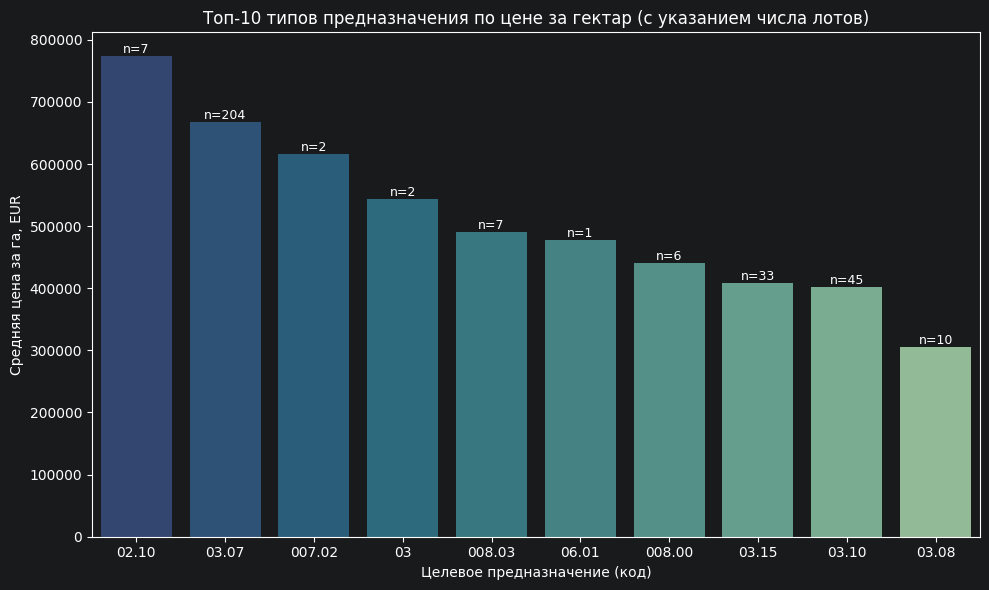

In [75]:
top10 = purpose_summary.head(10).reset_index()
top10['additional_classificator'] = top10['additional_classificator'].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='additional_classificator', y='avg_price_per_ha_eur', data=top10, order=top10['additional_classificator'], hue='additional_classificator', legend=False, palette='crest_r')

for i, row in top10.iterrows():
    ax.text(i, row['avg_price_per_ha_eur'], f"n={row['lots_count']}", ha='center', va='bottom', fontsize=9)

plt.xlabel('Целевое предназначение (код)')
plt.ylabel('Средняя цена за га, EUR')
plt.title('Топ-10 типов предназначения по цене за гектар (с указанием числа лотов)')
plt.tight_layout()
plt.show()

In [76]:
subset = auctions[
    (auctions['oblast'] == 'Київ') &
    (auctions['classificator'] == '06111000-3')
].copy()

print(len(subset))
subset[['auction_id', 'auction_date', 'land_area', 'sale_price_eur', 'price_per_ha_eur']].sort_values('auction_date')

3


,auction_id,auction_date,land_area,sale_price_eur,price_per_ha_eur
961,LSE001-UA-20221202-73619,2023-01-04,0.10,"31,916.74","319,167.41"
223,LSE001-UA-20230627-63608,2023-08-01,0.02,"30,384.01","1,519,200.63"
75,LSE001-UA-20230818-87424,2023-09-20,0.40,"766,205.24","1,919,832.73"


In [77]:
subset['additional_classificator'].value_counts()

additional_classificator
001.00    1
02.09     1
02.01     1
001.01    0
001.02    0
002.02    0
003.00    0
002.00    0
002.01    0
007.00    0
007.01    0
007.02    0
008.00    0
008.03    0
009.00    0
01        0
01.01     0
01.02     0
01.03     0
01.04     0
01.05     0
01.06     0
011.00    0
003.04    0
004.00    0
012.00    0
011.01    0
014.00    0
013.00    0
02        0
02.03     0
02.05     0
02.10     0
03        0
03.02     0
03.03     0
03.05     0
03.07     0
03.08     0
03.10     0
03.13     0
03.15     0
06.01     0
07.01     0
07.02     0
07.03     0
11        0
11.01     0
11.02     0
11.03     0
11.04     0
12        0
12.02     0
12.04     0
12.08     0
12.09     0
12.11     0
Name: count, dtype: int64

In [78]:
additional_classificator[additional_classificator['code'].isin(['001.00', '02.09', '02.01'])][['code', 'code_description']]

,code,code_description
8,02.09,Для будівництва і обслуговування паркінгів та автостоянок на землях житлової та громадської забудови
10,02.01,"Для будівництва і обслуговування житлового будинку, господарських будівель і споруд (присадибна ділянка)"
32,001.00,Рілля


In [79]:
subset[['auction_id', 'auction_date', 'land_area', 'additional_classificator', 'sale_price_eur', 'price_per_ha_eur']].merge(
    additional_classificator[['code', 'code_description']],
    left_on='additional_classificator', right_on='code', how='left'
)

,auction_id,auction_date,land_area,additional_classificator,sale_price_eur,price_per_ha_eur,code,code_description
0,LSE001-UA-20230818-87424,2023-09-20,0.40,02.09,"766,205.24","1,919,832.73",02.09,Для будівництва і обслуговування паркінгів та автостоянок на землях житлової та громадської забудови
1,LSE001-UA-20230627-63608,2023-08-01,0.02,001.00,"30,384.01","1,519,200.63",001.00,Рілля
2,LSE001-UA-20221202-73619,2023-01-04,0.10,02.01,"31,916.74","319,167.41",02.01,"Для будівництва і обслуговування житлового будинку, господарських будівель і споруд (присадибна ділянка)"


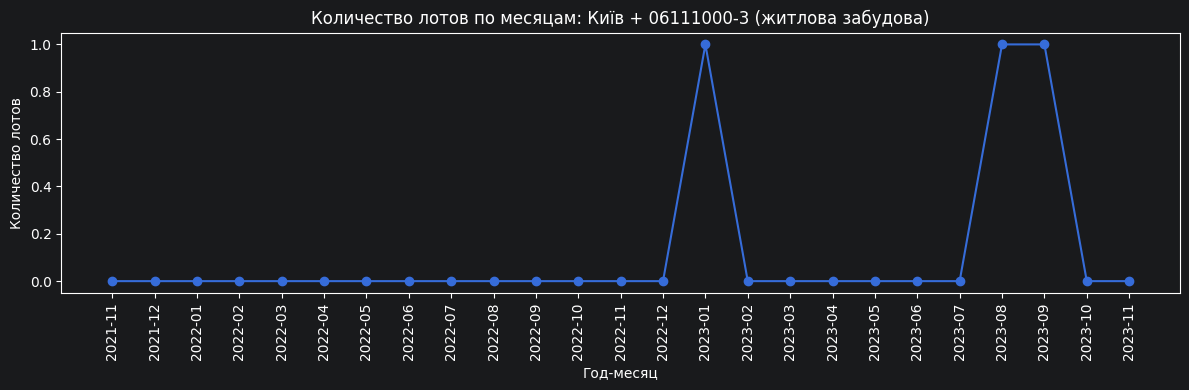

In [80]:
subset['year_month'] = subset['auction_date'].dt.to_period('M')

lots_by_month = subset.groupby('year_month').size()

full_range = pd.period_range(auctions['auction_date'].min().to_period('M'),
                              auctions['auction_date'].max().to_period('M'), freq='M')
lots_by_month = lots_by_month.reindex(full_range, fill_value=0)

plt.figure(figsize=(12, 4))
plt.plot(lots_by_month.index.astype(str), lots_by_month.values, marker='o')
plt.xticks(rotation=90)
plt.xlabel('Год-месяц')
plt.ylabel('Количество лотов')
plt.title('Количество лотов по месяцам: Київ + 06111000-3 (житлова забудова)')
plt.tight_layout()
plt.show()

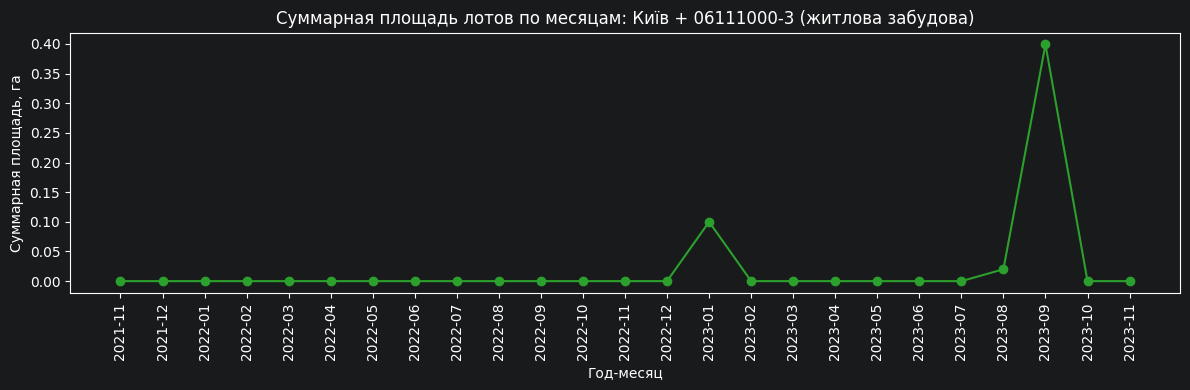

In [81]:
area_by_month = subset.groupby('year_month')['land_area'].sum(min_count=1)
area_by_month = area_by_month.reindex(full_range, fill_value=0)

plt.figure(figsize=(12, 4))
plt.plot(area_by_month.index.astype(str), area_by_month.values, marker='o', color='tab:green')
plt.xticks(rotation=90)
plt.xlabel('Год-месяц')
plt.ylabel('Суммарная площадь, га')
plt.title('Суммарная площадь лотов по месяцам: Київ + 06111000-3 (житлова забудова)')
plt.tight_layout()
plt.show()

In [82]:
subset_full = auctions[auctions['oblast'] == 'Київ'].copy()

print(len(subset_full))
subset_full[['auction_id', 'auction_date', 'classificator', 'additional_classificator',
             'land_area', 'sale_price_eur', 'price_per_ha_eur']].sort_values('auction_date')

6


,auction_id,auction_date,classificator,additional_classificator,land_area,sale_price_eur,price_per_ha_eur
1495,LSE001-UA-20211207-75102,2022-01-10,06112000-0,03.07,0.05,"130,257.83","2,605,156.62"
961,LSE001-UA-20221202-73619,2023-01-04,06111000-3,02.01,0.10,"31,916.74","319,167.41"
242,LSE001-UA-20230626-25407,2023-07-27,06121000-6,01,0.06,"12,853.56","216,389.88"
223,LSE001-UA-20230627-63608,2023-08-01,06111000-3,001.00,0.02,"30,384.01","1,519,200.63"
74,LSE001-UA-20230818-47146,2023-09-20,06128000-5,12.11,0.20,"207,207.44","1,039,676.05"
75,LSE001-UA-20230818-87424,2023-09-20,06111000-3,02.09,0.40,"766,205.24","1,919,832.73"


In [83]:
additional_classificator[additional_classificator['code'].isin(['01', '12.11'])][['code', 'code_description']]

,code,code_description
14,12.11,Для розміщення та експлуатації об'єктів дорожнього сервісу
25,01,Земельні ділянки сільськогосподарського призначення


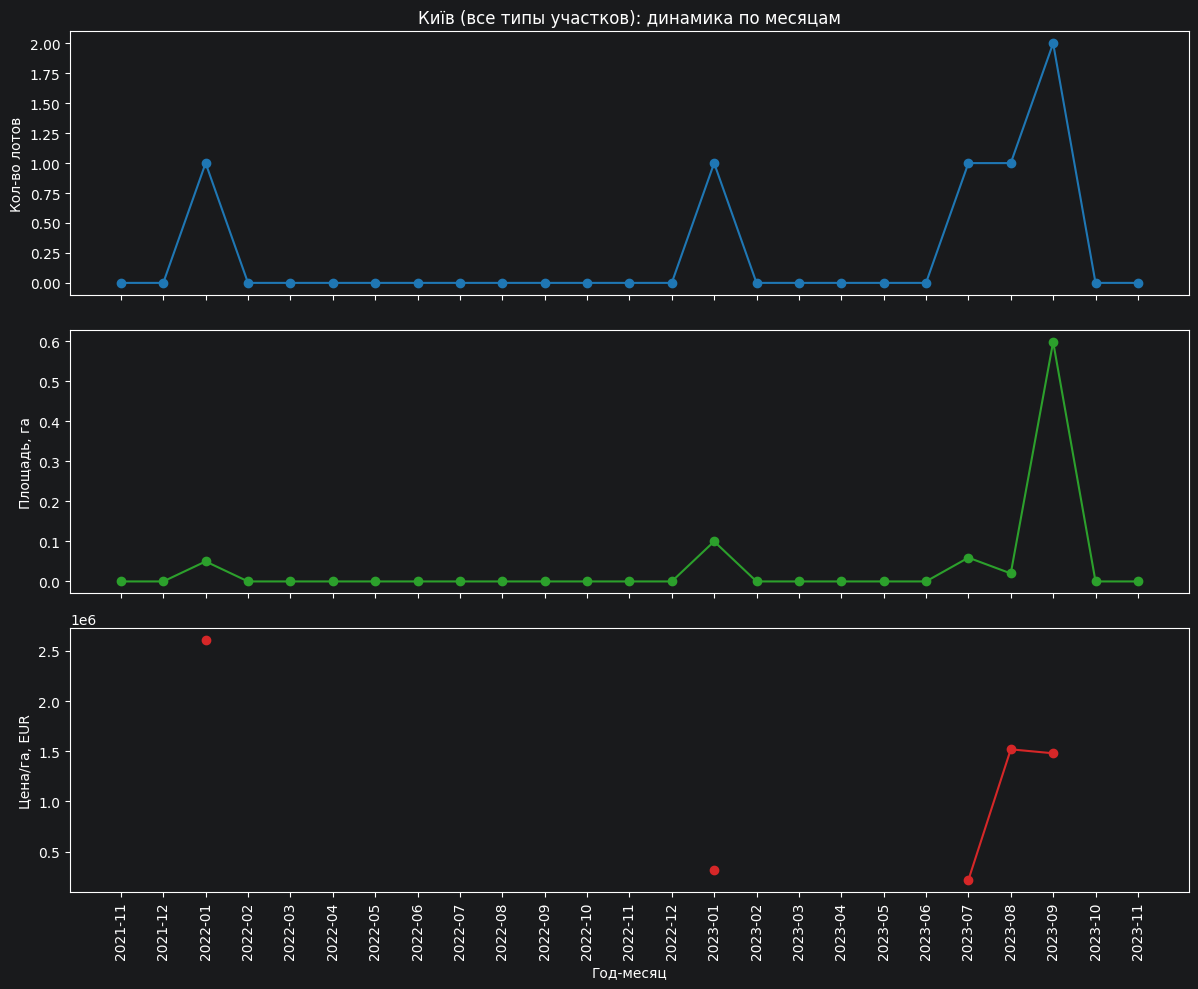

In [84]:
subset_full['year_month'] = subset_full['auction_date'].dt.to_period('M')

lots_by_month_full = subset_full.groupby('year_month').size().reindex(full_range, fill_value=0)
area_by_month_full = subset_full.groupby('year_month')['land_area'].sum(min_count=1).reindex(full_range, fill_value=0)
price_by_month_full = subset_full.groupby('year_month')['price_per_ha_eur'].mean().reindex(full_range)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(lots_by_month_full.index.astype(str), lots_by_month_full.values, marker='o', color='tab:blue')
axes[0].set_ylabel('Кол-во лотов')
axes[0].set_title('Київ (все типы участков): динамика по месяцам')

axes[1].plot(area_by_month_full.index.astype(str), area_by_month_full.values, marker='o', color='tab:green')
axes[1].set_ylabel('Площадь, га')

axes[2].plot(price_by_month_full.index.astype(str), price_by_month_full.values, marker='o', color='tab:red')
axes[2].set_ylabel('Цена/га, EUR')
axes[2].set_xlabel('Год-месяц')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()